In [1]:
import pandas as pd
import numpy as np
import pyreadr
import warnings
warnings.filterwarnings('ignore')

# Modelos
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree, export_text
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

# Evaluación
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    confusion_matrix, accuracy_score, classification_report
)

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


In [2]:
import sklearn
print(sklearn.__version__)

1.8.0


In [3]:
# Carga del dataset
result = pyreadr.read_r('listings.RData')
df_raw = list(result.values())[0].copy()

print(f'Filas: {df_raw.shape[0]} | Columnas: {df_raw.shape[1]}')
df_raw.head(3)

Filas: 171748 | Columnas: 80


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas"
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.69,4.63,NaN,f,1,1,0,0,0.28,"Austin, Texas"


In [4]:
# ── Preprocesamiento general ─────────────────────────────────────────────────
df = df_raw.copy()
df.columns = df.columns.str.strip()

# Limpiar columna price: eliminar $ y comas
df['price'] = df['price'].replace('[\$,]', '', regex=True)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Eliminar columnas no útiles (texto libre / identificadores)
cols_drop = ['id', 'host_id', 'listing_url', 'name', 'description',
             'neighborhood_overview', 'picture_url', 'host_url',
             'host_name', 'host_about', 'host_thumbnail_url',
             'host_picture_url', 'calendar_updated', 'last_scraped']
df = df.drop(columns=[c for c in cols_drop if c in df.columns])

# Eliminar columnas de fecha (no útiles sin ingeniería de features extra)
date_cols = [c for c in df.columns if 'date' in c.lower() or 'since' in c.lower()]
df = df.drop(columns=date_cols, errors='ignore')

# Columnas booleanas t/f → 1/0
for col in df.select_dtypes(include='object').columns:
    vals = df[col].dropna().unique()
    if set(vals).issubset({'t', 'f'}):
        df[col] = df[col].map({'t': 1, 'f': 0})

# Porcentajes → numérico
for col in df.select_dtypes(include='object').columns:
    if df[col].astype(str).str.contains('%', na=False).any():
        df[col] = df[col].astype(str).str.replace('%', '', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Encoding de categóricas con cardinalidad baja
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_validas = [c for c in cat_cols if df[c].nunique() < 20]
df = pd.get_dummies(df, columns=cat_validas, drop_first=True)

# Eliminar restantes de texto libre
remaining_obj = df.select_dtypes(include='object').columns.tolist()
df = df.drop(columns=remaining_obj, errors='ignore')

# Eliminar filas con nulos
df = df.dropna(subset=['price'])

# Eliminar outliers extremos de precio (por encima del percentil 99)
p99 = df['price'].quantile(0.99)
df = df[df['price'] <= p99]

print(f'Dataset limpio → Filas: {df.shape[0]} | Columnas: {df.shape[1]}')
df['price'].describe()

Dataset limpio → Filas: 75531 | Columnas: 98


count    75531.000000
mean       347.944275
std        854.852946
min          8.000000
25%        119.000000
50%        191.000000
75%        320.000000
max      20000.000000
Name: price, dtype: float64

In [5]:
X = df.drop(columns=['price'])
y = df['price']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=123
)

from sklearn.impute import SimpleImputer
import pandas as pd

imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Usar columnas válidas del imputer
cols = X_train.columns[~X_train.isna().all()]

X_train = pd.DataFrame(X_train_imputed, columns=cols)
X_test = pd.DataFrame(X_test_imputed, columns=cols)
print(f'Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas')
print(f'Precio medio train: ${y_train.mean():.2f} | test: ${y_test.mean():.2f}')

Train: 52871 filas | Test: 22660 filas
Precio medio train: $347.31 | test: $349.42


In [6]:
# arbol sin restriccion de profundidad
arbol_base = DecisionTreeRegressor(random_state=123)
arbol_base.fit(X_train, y_train)

print(f'Profundidad del árbol base: {arbol_base.get_depth()}')
print(f'Número de hojas: {arbol_base.get_n_leaves()}')

Profundidad del árbol base: 53
Número de hojas: 48138


In [7]:
def evaluar_regresion(model, X_tr, y_tr, X_te, y_te, nombre='Modelo'):
    """Calcula RMSE, MAE y R² en train y test."""
    pred_tr = model.predict(X_tr)
    pred_te = model.predict(X_te)
    metricas = {
        'Modelo': nombre,
        'RMSE_train': np.sqrt(mean_squared_error(y_tr, pred_tr)),
        'RMSE_test':  np.sqrt(mean_squared_error(y_te, pred_te)),
        'MAE_test':   mean_absolute_error(y_te, pred_te),
        'R2_train':   r2_score(y_tr, pred_tr),
        'R2_test':    r2_score(y_te, pred_te),
    }
    return metricas

met_base = evaluar_regresion(arbol_base, X_train, y_train, X_test, y_test, 'Árbol base (sin poda)')
pd.DataFrame([met_base]).set_index('Modelo').round(2)

,RMSE_train,RMSE_test,MAE_test,R2_train,R2_test
Modelo,,,,,
Árbol base (sin poda),81.92,526.09,148.52,0.99,0.66


In [8]:
profundidades = [3, 5, 7, 10, 15, None]
resultados_reg = []

for depth in profundidades:
    m = DecisionTreeRegressor(max_depth=depth, random_state=123)
    m.fit(X_train, y_train)
    nombre = f'depth={depth}' if depth else 'Sin poda'
    met = evaluar_regresion(m, X_train, y_train, X_test, y_test, nombre)
    resultados_reg.append(met)

df_reg = pd.DataFrame(resultados_reg).set_index('Modelo')
print(df_reg.round(2))

          RMSE_train  RMSE_test  MAE_test  R2_train  R2_test
Modelo                                                      
depth=3       556.04     589.52    197.45      0.55     0.57
depth=5       503.01     536.23    180.22      0.64     0.65
depth=7       447.69     497.86    160.09      0.71     0.70
depth=10      339.27     472.12    145.89      0.83     0.73
depth=15      178.90     489.45    137.21      0.95     0.71
Sin poda       81.92     526.09    148.52      0.99     0.66


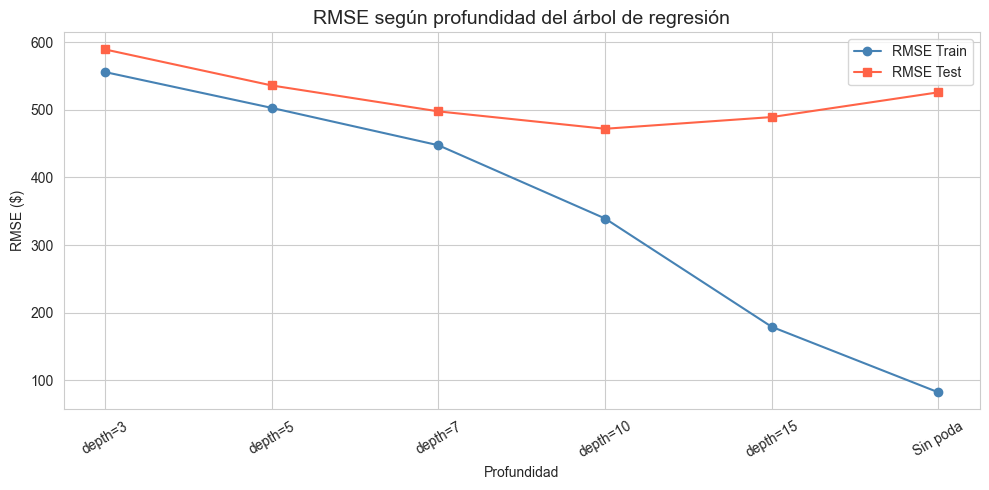


Mejor profundidad para regresión: depth=10
RMSE_train    339.27
RMSE_test     472.12
MAE_test      145.89
R2_train        0.83
R2_test         0.73
Name: depth=10, dtype: float64


In [9]:
# Gráfica RMSE train vs test según profundidad
etiquetas = [str(r['Modelo']) for r in resultados_reg]
rmse_train = df_reg['RMSE_train'].values
rmse_test  = df_reg['RMSE_test'].values

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(etiquetas, rmse_train, marker='o', label='RMSE Train', color='steelblue')
ax.plot(etiquetas, rmse_test,  marker='s', label='RMSE Test',  color='tomato')
ax.set_title('RMSE según profundidad del árbol de regresión', fontsize=14)
ax.set_xlabel('Profundidad')
ax.set_ylabel('RMSE ($)')
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

mejor_depth_reg = df_reg['RMSE_test'].idxmin()
print(f'\nMejor profundidad para regresión: {mejor_depth_reg}')
print(df_reg.loc[mejor_depth_reg].round(2))

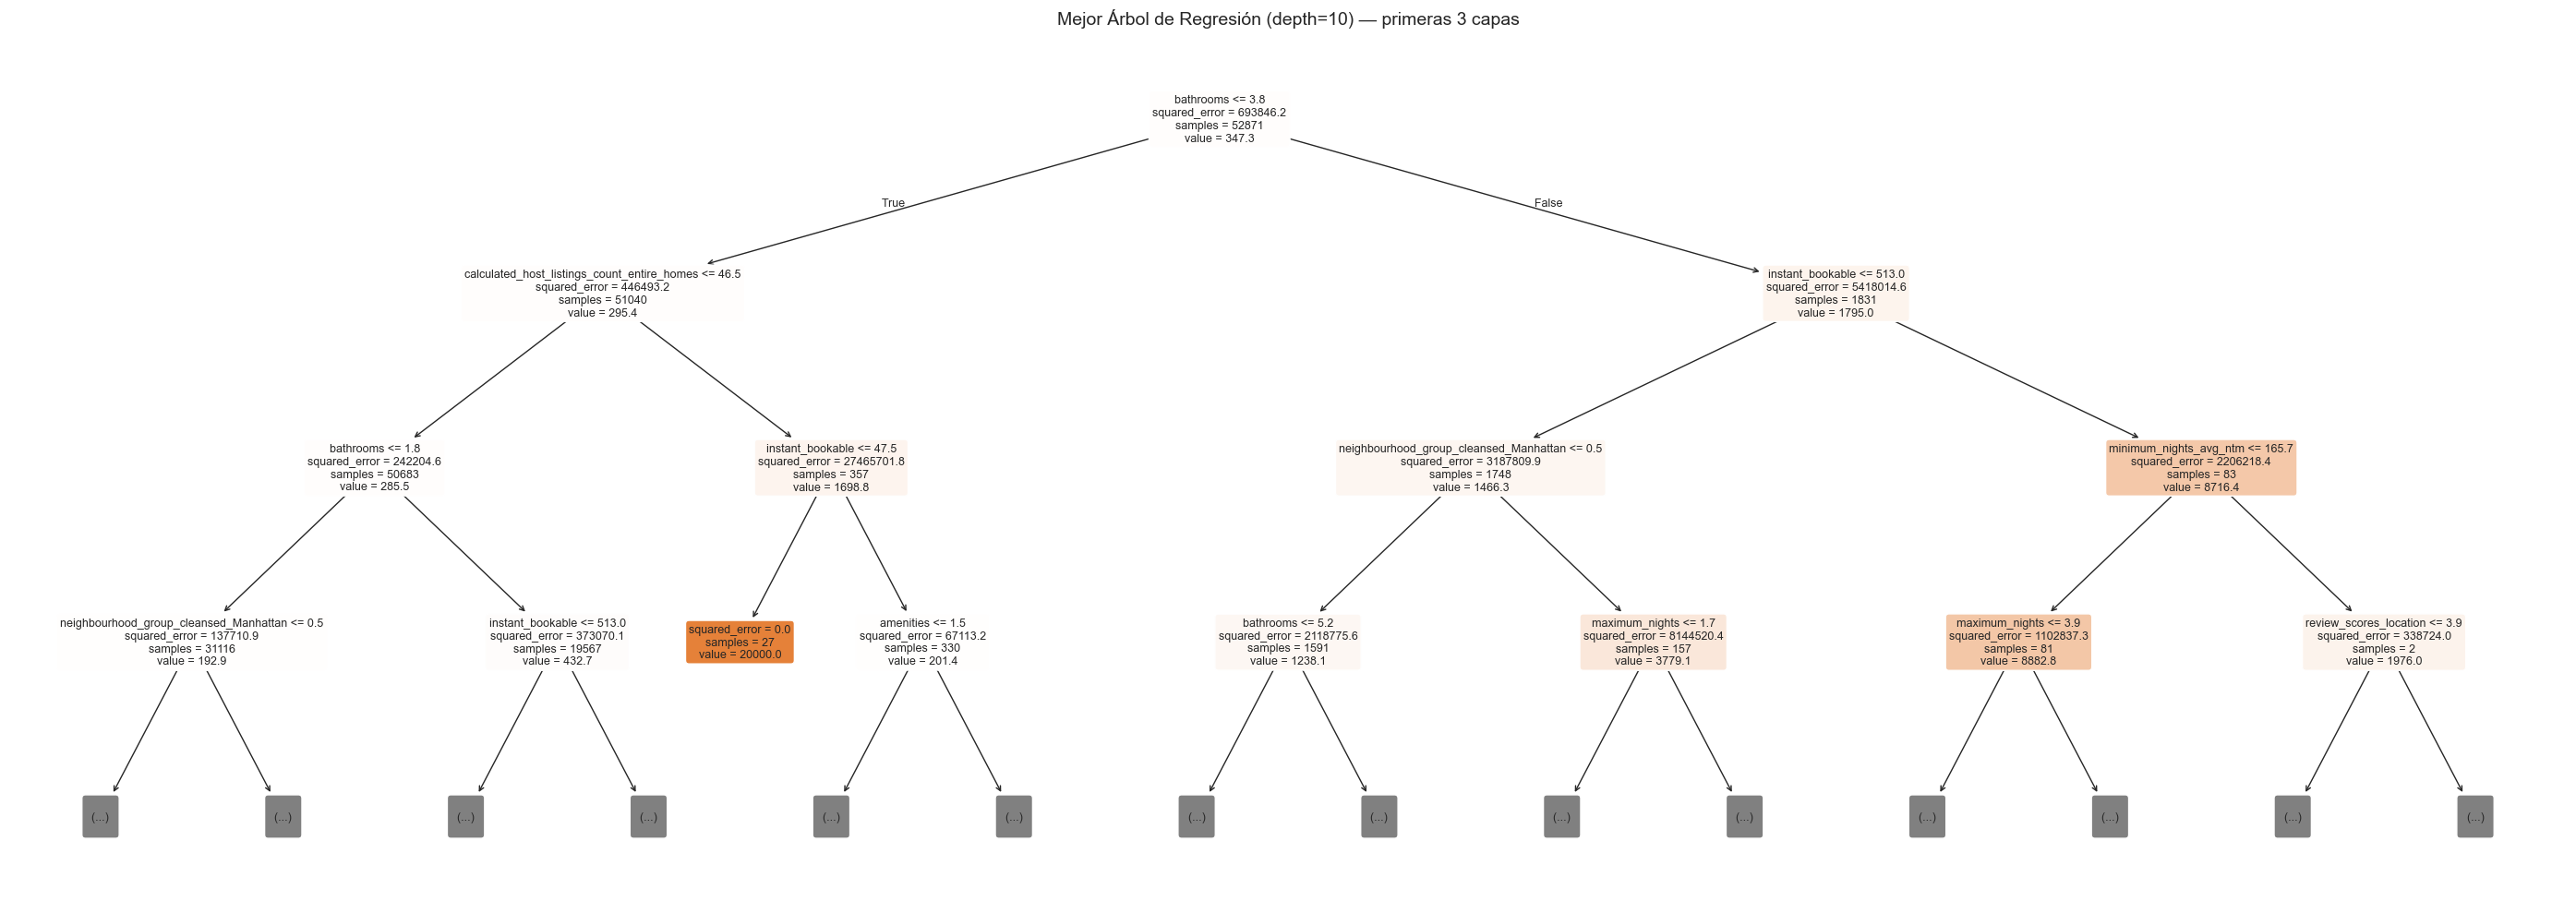

In [10]:
# Extraer la profundidad numérica del índice para reutilizarla
mejor_depth_num = None
for depth in profundidades:
    nombre = f'depth={depth}' if depth else 'Sin poda'
    if nombre == mejor_depth_reg:
        mejor_depth_num = depth
        break

mejor_arbol_reg = DecisionTreeRegressor(max_depth=mejor_depth_num, random_state=123)
mejor_arbol_reg.fit(X_train, y_train)

# Visualización del mejor árbol (primeras 3 capas)
plt.figure(figsize=(28, 10))
plot_tree(mejor_arbol_reg, filled=True, feature_names=list(X.columns),
          max_depth=3, fontsize=9, precision=1, rounded=True)
plt.title(f'Mejor Árbol de Regresión ({mejor_depth_reg}) — primeras 3 capas', fontsize=14)
plt.tight_layout()
plt.show()

In [11]:

# Regresión lineal
lm = LinearRegression()
lm.fit(X_train, y_train)
met_lm = evaluar_regresion(lm, X_train, y_train, X_test, y_test, 'Regresión Lineal')

# Mejor árbol de regresión
met_mejor_arbol = evaluar_regresion(mejor_arbol_reg, X_train, y_train, X_test, y_test,
                                     f'Árbol Regresión ({mejor_depth_reg})')

comparacion = pd.DataFrame([met_lm, met_mejor_arbol]).set_index('Modelo')
print(comparacion.round(2))

                            RMSE_train  RMSE_test  MAE_test  R2_train  R2_test
Modelo                                                                        
Regresión Lineal                749.80     828.34    265.32      0.19     0.16
Árbol Regresión (depth=10)      339.27     472.12    145.89      0.83     0.73


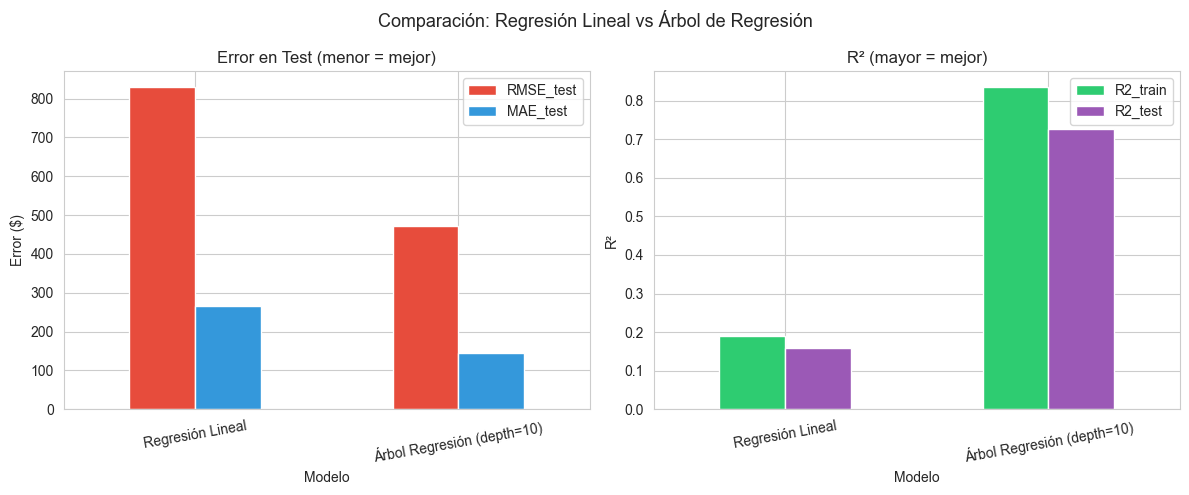

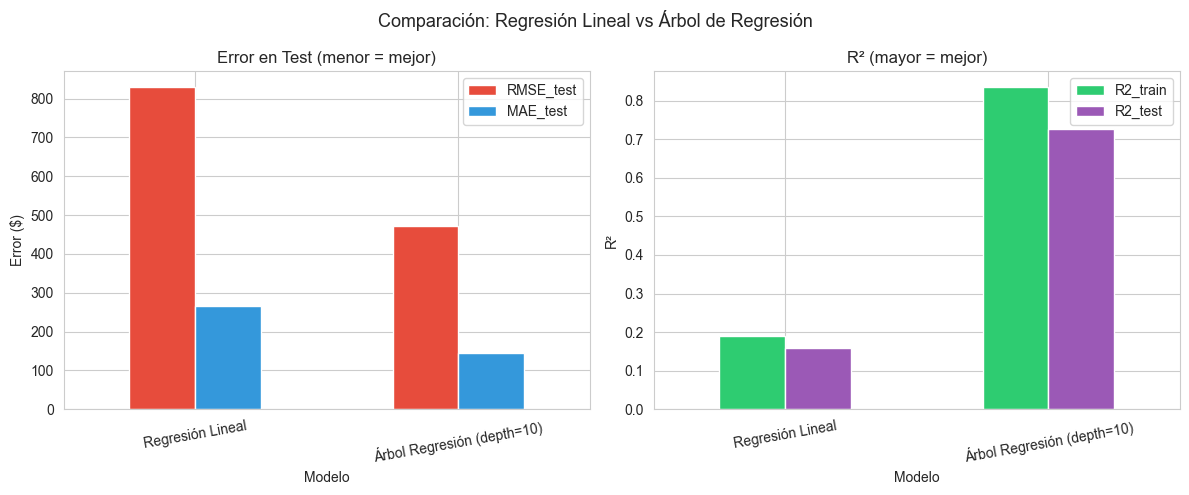

In [12]:
# Gráfica de comparación
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

comparacion[['RMSE_test', 'MAE_test']].plot(kind='bar', ax=axes[0], color=['#e74c3c','#3498db'], rot=10)
axes[0].set_title('Error en Test (menor = mejor)')
axes[0].set_ylabel('Error ($)')

comparacion[['R2_train', 'R2_test']].plot(kind='bar', ax=axes[1], color=['#2ecc71','#9b59b6'], rot=10)
axes[1].set_title('R² (mayor = mejor)')
axes[1].set_ylabel('R²')

plt.suptitle('Comparación: Regresión Lineal vs Árbol de Regresión', fontsize=13)
plt.tight_layout()
plt.show()# Gráfica de comparación
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

comparacion[['RMSE_test', 'MAE_test']].plot(kind='bar', ax=axes[0], color=['#e74c3c','#3498db'], rot=10)
axes[0].set_title('Error en Test (menor = mejor)')
axes[0].set_ylabel('Error ($)')

comparacion[['R2_train', 'R2_test']].plot(kind='bar', ax=axes[1], color=['#2ecc71','#9b59b6'], rot=10)
axes[1].set_title('R² (mayor = mejor)')
axes[1].set_ylabel('R²')

plt.suptitle('Comparación: Regresión Lineal vs Árbol de Regresión', fontsize=13)
plt.tight_layout()
plt.show()

In [13]:
# Análisis de distribución de precios
stats_precio = df['price'].describe(percentiles=[0.10, 0.25, 0.33, 0.50, 0.66, 0.75, 0.90])
print('Estadísticos del precio por noche:')
print(stats_precio.round(2))

Estadísticos del precio por noche:
count    75531.00
mean       347.94
std        854.85
min          8.00
10%         80.00
25%        119.00
33%        140.00
50%        191.00
66%        260.00
75%        320.00
90%        594.00
max      20000.00
Name: price, dtype: float64


In [14]:
p33 = df['price'].quantile(0.33)
p66 = df['price'].quantile(0.66)

print(f'Límite inferior (p33): ${p33:.2f}')
print(f'Límite superior (p66): ${p66:.2f}')
print(f'\nCategorías:')
print(f'  Económica  → precio ≤ ${p33:.2f}')
print(f'  Intermedia → ${p33:.2f} < precio ≤ ${p66:.2f}')
print(f'  Cara       → precio > ${p66:.2f}')

# Crear la variable categórica
def clasificar_precio(x):
    if x <= p33:
        return 'Economica'
    elif x <= p66:
        return 'Intermedia'
    else:
        return 'Cara'

df['precio_cat'] = df['price'].apply(clasificar_precio)

print('\nDistribución de clases:')
print(df['precio_cat'].value_counts())

Límite inferior (p33): $140.00
Límite superior (p66): $260.00

Categorías:
  Económica  → precio ≤ $140.00
  Intermedia → $140.00 < precio ≤ $260.00
  Cara       → precio > $260.00

Distribución de clases:
precio_cat
Cara          25628
Intermedia    24968
Economica     24935
Name: count, dtype: int64


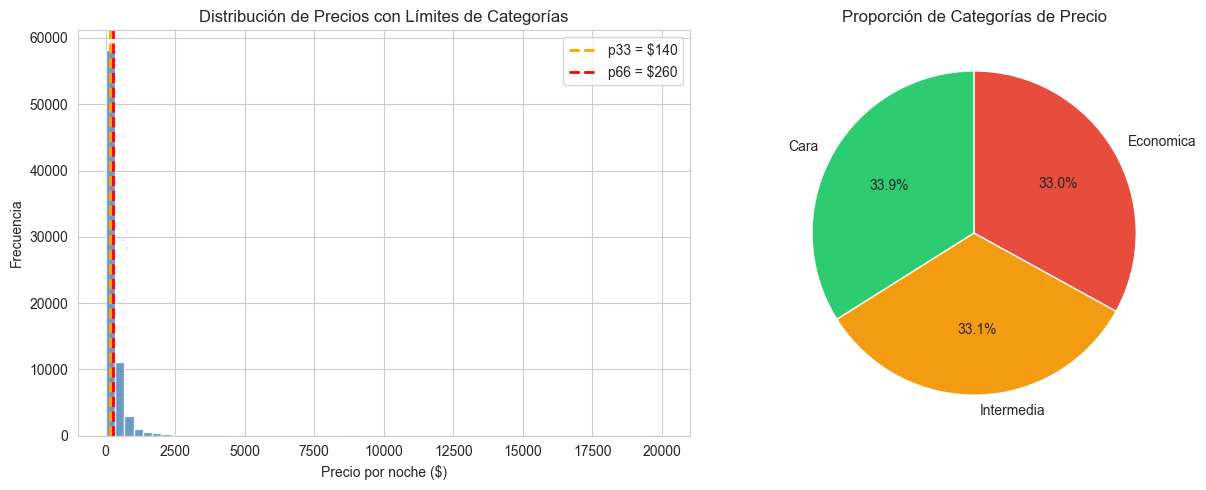

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histograma con líneas de corte
axes[0].hist(df['price'], bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(p33, color='orange', linestyle='--', linewidth=2, label=f'p33 = ${p33:.0f}')
axes[0].axvline(p66, color='red',    linestyle='--', linewidth=2, label=f'p66 = ${p66:.0f}')
axes[0].set_title('Distribución de Precios con Límites de Categorías')
axes[0].set_xlabel('Precio por noche ($)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Gráfico de pastel
conteo = df['precio_cat'].value_counts()
colores = ['#2ecc71', '#f39c12', '#e74c3c']
axes[1].pie(conteo, labels=conteo.index, autopct='%1.1f%%',
            colors=colores, startangle=90)
axes[1].set_title('Proporción de Categorías de Precio')

plt.tight_layout()
plt.show()

In [16]:
# Features: excluir precio Y la variable categórica
X_clas = df.drop(columns=['price', 'precio_cat'])
y_clas = df['precio_cat']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clas, y_clas, test_size=0.3, random_state=123, stratify=y_clas
)

print(f'Train clasificación: {X_train_c.shape[0]} | Test: {X_test_c.shape[0]}')
print('Distribución train:')
print(y_train_c.value_counts())

Train clasificación: 52871 | Test: 22660
Distribución train:
precio_cat
Cara          17939
Intermedia    17478
Economica     17454
Name: count, dtype: int64
